# Part 1: Cost Structure & Budget Optimization 분석

> **목적:** DGP에 추가된 비용 레이어를 탐색하고, Ground Truth 최적 예산 배분을 시각화한다.
> "Effect(전환 기여) ≠ Efficiency(비용 대비 효율)" 인사이트를 도출하며,
> 실험 07(Budget Optimization 평가)의 결과를 분석한다.
>
> **데이터:** `data/simulation/journeys.parquet`, `cost_summary.json`, `ground_truth.json`, `results/part1/07_budget_optimization.csv`

---

## 목차
1. **Cost 분포 탐색** — 채널별 지출, 세그먼트별 단가
2. **Ground Truth Budget** — Marginal Effect, Efficiency, Optimal Allocation
3. **Effect vs Efficiency** — Paid Search 역설
4. **Experiment 07** — 17개 방법론 Budget Allocation 평가
5. **결론** — 가설 검증 및 실무적 시사점

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from part1_simulation.notebook_setup import setup_notebook, METHOD_CATEGORIES, CATEGORY_COLORS
setup_notebook()

%matplotlib inline

CHANNEL_COLORS = {
    "Paid Search": "#E74C3C", "Email": "#3498DB", "Display": "#2ECC71",
    "Social": "#F39C12", "Organic Search": "#9B59B6",
    "Direct": "#1ABC9C", "Referral": "#95A5A6",
}

# --- Load data ---
journeys = pd.read_parquet("../../data/simulation/journeys.parquet")

with open("../../data/simulation/cost_summary.json") as f:
    cost_summary = json.load(f)

with open("../../data/simulation/ground_truth.json") as f:
    gt = json.load(f)

gt_a = gt["ground_truth_A"]["channel_credits"]
gt_budget = gt["ground_truth_budget"]

print(f"Journeys: {len(journeys):,} rows, {journeys['user_id'].nunique():,} users")
print(f"Converters: {cost_summary['n_converters']:,}")
print(f"Total spend: ${cost_summary['total_spend']:,.2f}")
print(f"CPA: ${cost_summary['cost_per_conversion']:.2f}")

Journeys: 517,893 rows, 100,000 users
Converters: 2,305
Total spend: $205,903.38
CPA: $89.33


---
## 1. Cost 분포 탐색

### 1.1 채널별 지출 분포

Cost는 observation layer로서 전환 확률에 영향을 주지 않는다. 비용 유형:
- **CPM**: Display ($0.005/TP), Social ($0.008/TP)
- **CPC**: Paid Search ($2.50/TP)
- **Fixed**: Email ($0.003/TP)
- **Zero**: Organic Search, Referral, Direct

=== Channel Cost Summary ===
                touchpoints  total_spend  avg_cost  spend_pct
channel                                                      
Paid Search           78606     $204,645    $2.603        $99
Social                72017         $683    $0.009     $0.332
Display               61491         $348    $0.006     $0.169
Email                 75213         $227    $0.003     $0.110
Direct                80495       $0.000    $0.000     $0.000
Organic Search        99154       $0.000    $0.000     $0.000
Referral              50917       $0.000    $0.000     $0.000


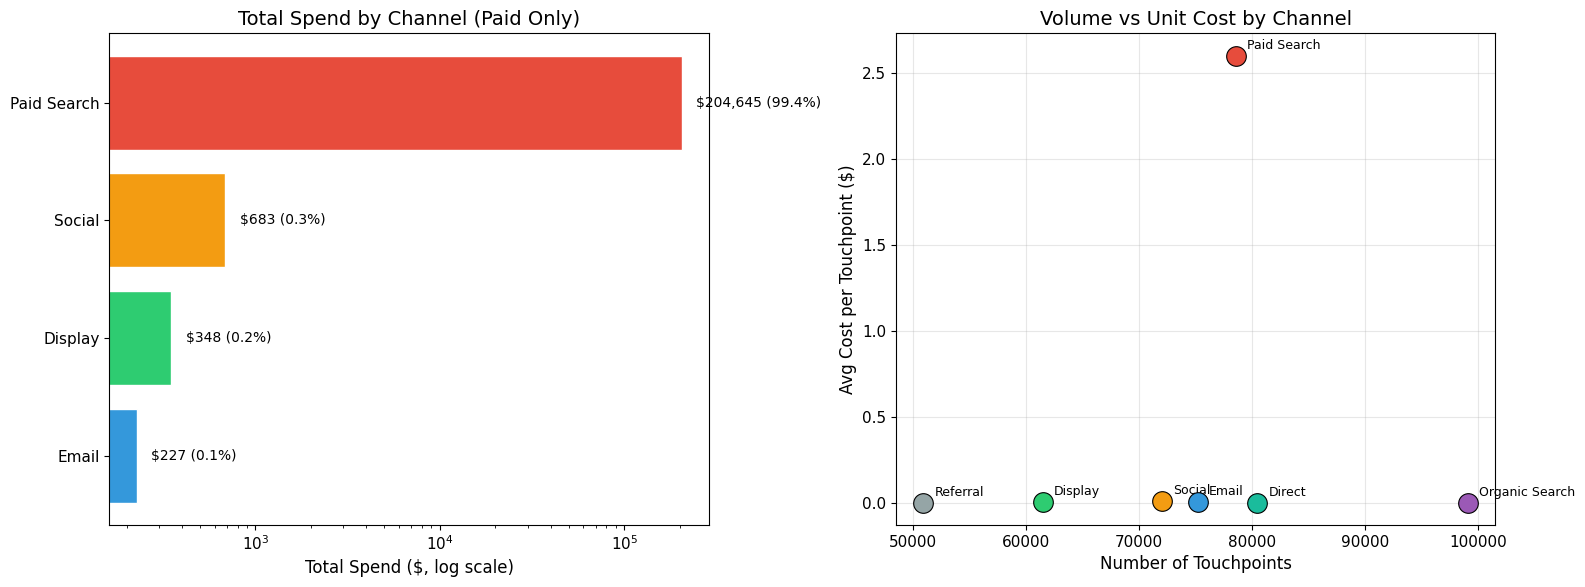

In [2]:
# Channel cost summary table
cost_df = (
    journeys.groupby("channel", observed=True)
    .agg(
        touchpoints=("touchpoint_cost", "count"),
        total_spend=("touchpoint_cost", "sum"),
        avg_cost=("touchpoint_cost", "mean"),
    )
    .sort_values("total_spend", ascending=False)
    .assign(spend_pct=lambda df: df["total_spend"] / df["total_spend"].sum() * 100)
)

print("=== Channel Cost Summary ===")
print(cost_df.to_string(float_format=lambda x: f"${x:,.3f}" if x < 10 else f"${x:,.0f}"))

# --- Visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total spend by channel (log scale bar)
paid_df = cost_df[cost_df["total_spend"] > 0].sort_values("total_spend")
colors = [CHANNEL_COLORS.get(ch, "#999") for ch in paid_df.index]
ax1.barh(paid_df.index, paid_df["total_spend"], color=colors, edgecolor="white")
ax1.set_xscale("log")
ax1.set_xlabel("Total Spend ($, log scale)")
ax1.set_title("Total Spend by Channel (Paid Only)")
for i, (ch, row) in enumerate(paid_df.iterrows()):
    ax1.text(row["total_spend"] * 1.2, i, f"${row['total_spend']:,.0f} ({row['spend_pct']:.1f}%)",
             va="center", fontsize=10)

# Right: Touchpoint count vs avg cost scatter
all_channels = cost_df.index.tolist()
for ch in all_channels:
    row = cost_df.loc[ch]
    color = CHANNEL_COLORS.get(ch, "#999")
    ax2.scatter(row["touchpoints"], row["avg_cost"], c=color, s=200,
                edgecolor="black", linewidth=0.8, zorder=3)
    offset_x = 1500 if row["avg_cost"] > 0.01 else 1500
    ax2.annotate(ch, (row["touchpoints"], row["avg_cost"]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

ax2.set_xlabel("Number of Touchpoints")
ax2.set_ylabel("Avg Cost per Touchpoint ($)")
ax2.set_title("Volume vs Unit Cost by Channel")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2 세그먼트별 비용 차이

New(Prospecting) 유저는 넓은 타겟팅으로 비용이 높고, Loyal(Retargeting)은 좁은 오디언스로 비용이 낮다.

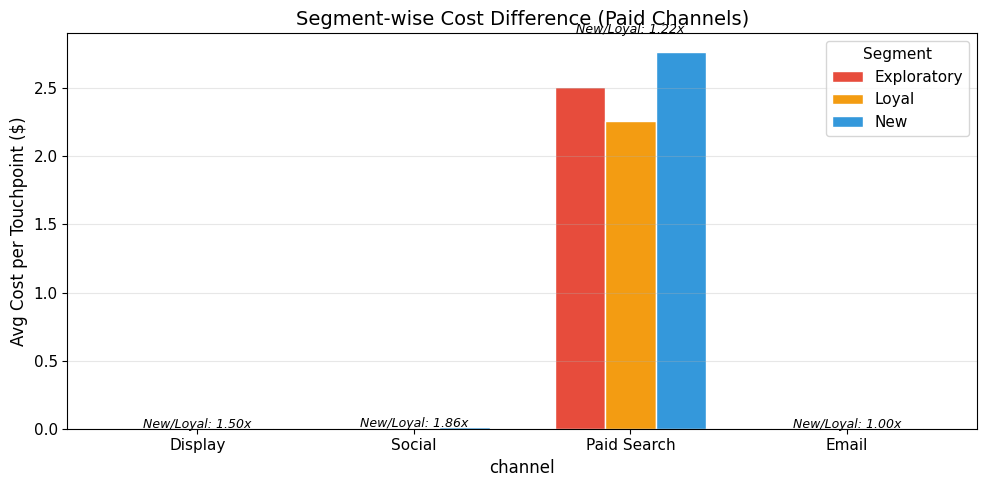


Segment × Channel avg cost:
segment      Exploratory  Loyal    New
channel                               
Display           0.0050 0.0040 0.0060
Social            0.0080 0.0056 0.0105
Paid Search       2.5126 2.2623 2.7658
Email             0.0030 0.0030 0.0030


In [3]:
# Segment × Channel average cost (paid channels only)
paid_channels = ["Display", "Social", "Paid Search", "Email"]
paid_mask = journeys["channel"].isin(paid_channels)

seg_cost = (
    journeys[paid_mask]
    .groupby(["channel", "segment"], observed=True)["touchpoint_cost"]
    .mean()
    .unstack("segment")
    .reindex(paid_channels)
)

fig, ax = plt.subplots(figsize=(10, 5))
seg_cost.plot(kind="bar", ax=ax, color=["#E74C3C", "#F39C12", "#3498DB"],
              edgecolor="white", width=0.7)
ax.set_ylabel("Avg Cost per Touchpoint ($)")
ax.set_title("Segment-wise Cost Difference (Paid Channels)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Segment")
ax.grid(axis="y", alpha=0.3)

# Annotate multiplier ratios
for i, ch in enumerate(paid_channels):
    if ch in seg_cost.index:
        new_cost = seg_cost.loc[ch, "New"]
        loyal_cost = seg_cost.loc[ch, "Loyal"]
        if loyal_cost > 0:
            ratio = new_cost / loyal_cost
            ax.text(i, max(seg_cost.loc[ch]) * 1.05,
                    f"New/Loyal: {ratio:.2f}x", ha="center", fontsize=9, style="italic")

plt.tight_layout()
plt.show()

print("\nSegment × Channel avg cost:")
print(seg_cost.to_string(float_format="%.4f"))

---
## 2. Ground Truth Budget — Marginal Effect, Efficiency, Optimal Allocation

DGP 파라미터(β, decay half-life)로부터 도출한 ground truth:
- **Marginal Effect** = β_k × E[f_k(Δt)] — 채널 k의 터치포인트 1회당 전환 기여
- **Efficiency** = Marginal Effect / Cost per TP — 1달러당 전환 기여
- **Optimal Allocation** (Linear Response) — 효율성 비례 배분

In [4]:
# Build summary DataFrame from ground truth budget
effects = gt_budget["marginal_effects"]
efficiency = gt_budget["channel_efficiency"]
alloc_frac = gt_budget["optimal_allocation_fraction"]
alloc_dollars = gt_budget["optimal_allocation_dollars"]

# All channels marginal effects
effects_df = (
    pd.DataFrame([
        {"channel": ch, "marginal_effect": eff}
        for ch, eff in effects.items()
    ])
    .sort_values("marginal_effect", ascending=False)
)

# Paid channels efficiency + allocation
paid_df = (
    pd.DataFrame([
        {
            "channel": ch,
            "marginal_effect": effects[ch],
            "efficiency": efficiency[ch],
            "alloc_pct": alloc_frac[ch] * 100,
            "alloc_dollars": alloc_dollars[ch],
        }
        for ch in efficiency
    ])
    .sort_values("efficiency", ascending=False)
)

print("=== All Channels: Marginal Effect (beta x avg_decay) ===")
for _, row in effects_df.iterrows():
    print(f"  {row['channel']:20s}: {row['marginal_effect']:.4f}")

print(f"\n=== Paid Channels: Efficiency & Optimal Allocation ===")
print(paid_df.to_string(index=False, float_format="%.2f"))

=== All Channels: Marginal Effect (beta x avg_decay) ===
  Paid Search         : 0.4679
  Email               : 0.4580
  Direct              : 0.3262
  Referral            : 0.2683
  Organic Search      : 0.2320
  Display             : 0.1915
  Social              : 0.1285

=== Paid Channels: Efficiency & Optimal Allocation ===
    channel  marginal_effect  efficiency  alloc_pct  alloc_dollars
      Email             0.46      152.67      73.67      147345.30
    Display             0.19       38.30      18.48       36968.67
     Social             0.13       16.07       7.75       15505.39
Paid Search             0.47        0.19       0.09         180.64


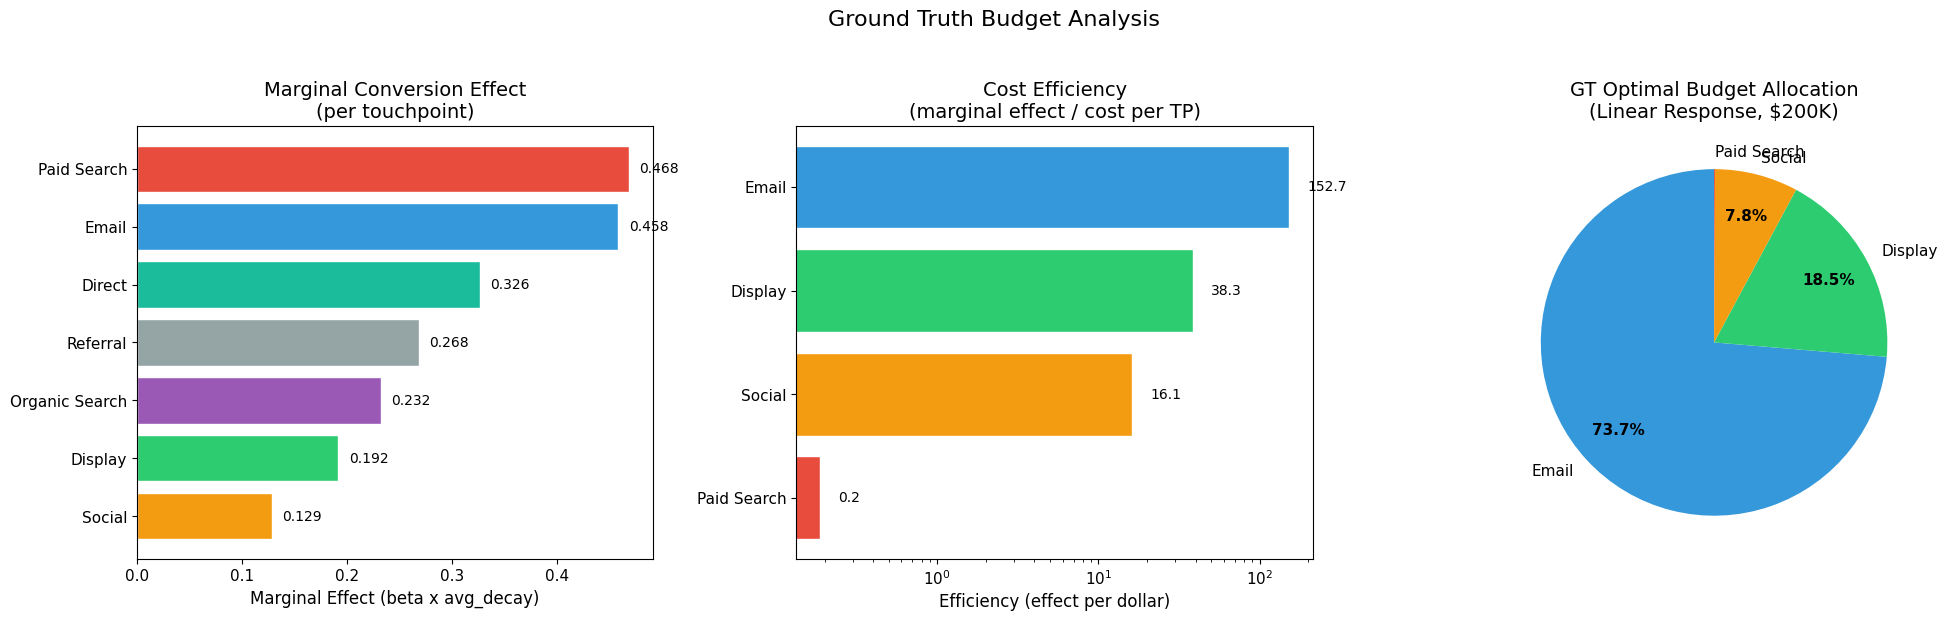

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- 1. Marginal Effect (all channels) ---
ax = axes[0]
df = effects_df.sort_values("marginal_effect")
colors = [CHANNEL_COLORS.get(ch, "#999") for ch in df["channel"]]
ax.barh(df["channel"], df["marginal_effect"], color=colors, edgecolor="white")
ax.set_xlabel("Marginal Effect (beta x avg_decay)")
ax.set_title("Marginal Conversion Effect\n(per touchpoint)")
for i, (_, row) in enumerate(df.iterrows()):
    ax.text(row["marginal_effect"] + 0.01, i, f"{row['marginal_effect']:.3f}",
            va="center", fontsize=10)

# --- 2. Efficiency (paid channels only) ---
ax = axes[1]
df2 = paid_df.sort_values("efficiency")
colors2 = [CHANNEL_COLORS.get(ch, "#999") for ch in df2["channel"]]
ax.barh(df2["channel"], df2["efficiency"], color=colors2, edgecolor="white")
ax.set_xlabel("Efficiency (effect per dollar)")
ax.set_title("Cost Efficiency\n(marginal effect / cost per TP)")
ax.set_xscale("log")
for i, (_, row) in enumerate(df2.iterrows()):
    ax.text(row["efficiency"] * 1.3, i, f"{row['efficiency']:.1f}",
            va="center", fontsize=10)

# --- 3. Optimal Allocation (paid channels) ---
ax = axes[2]
df3 = paid_df.sort_values("alloc_pct", ascending=False)
colors3 = [CHANNEL_COLORS.get(ch, "#999") for ch in df3["channel"]]
wedges, texts, autotexts = ax.pie(
    df3["alloc_pct"], labels=df3["channel"], colors=colors3,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90, pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
ax.set_title("GT Optimal Budget Allocation\n(Linear Response, $200K)")

plt.suptitle("Ground Truth Budget Analysis", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

---
## 3. Effect vs Efficiency — Paid Search 역설

> **핵심 인사이트**: Paid Search는 **전환 기여(effect) 1위**이지만 비용 대비 **효율(efficiency) 최하위**이다.
>
> 이 역전은 현실 마케팅에서 흔한 패턴이다: 성과형 매체(CPC)는 클릭당 비용이 높아 ROI가 낮을 수 있고,
> near-zero cost 채널(Email)은 발송 비용이 극히 낮아 효율이 압도적이다.
>
> **실무적 함의**: Last Click 같은 lower-funnel 편향 방법론은 Paid Search의 높은 effect만 보고
> 예산을 집중시키지만, 비용 효율성을 고려하면 Email/Display로 재배분이 필요하다.

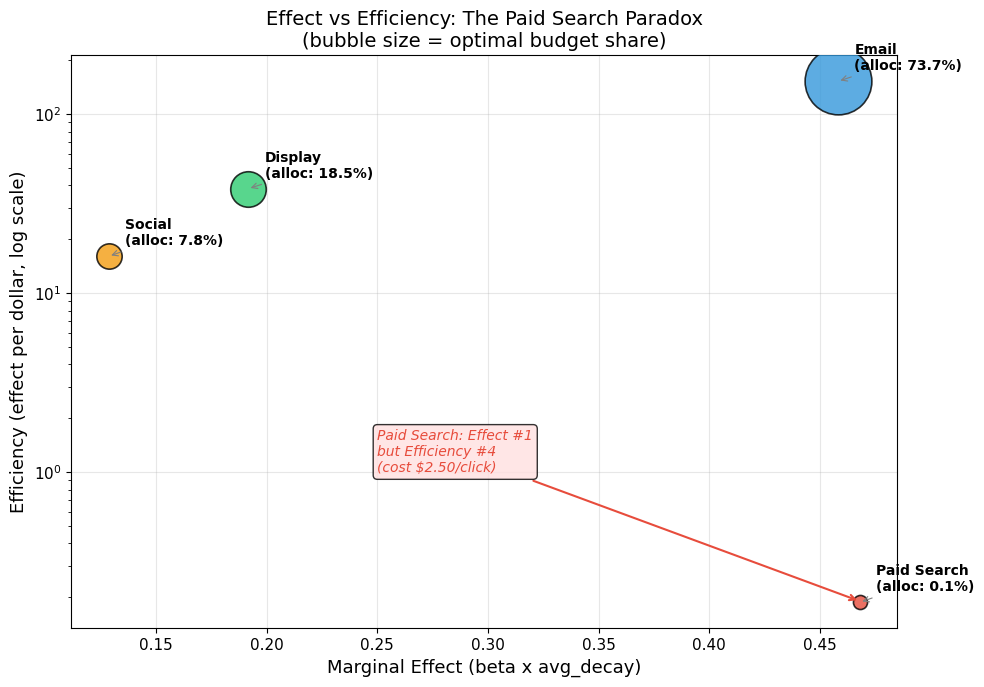

=== Current Spend vs GT Optimal ===
  Email               : actual $       227  optimal $   147,345  (under-spend)
  Display             : actual $       348  optimal $    36,969  (under-spend)
  Social              : actual $       683  optimal $    15,505  (under-spend)
  Paid Search         : actual $   204,645  optimal $       181  (over-spend)


In [6]:
# Effect vs Efficiency comparison (paid channels)
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in paid_df.iterrows():
    ch = row["channel"]
    color = CHANNEL_COLORS.get(ch, "#999")
    size = row["alloc_pct"] * 30 + 100  # bubble size ~ optimal allocation
    ax.scatter(row["marginal_effect"], row["efficiency"], c=color, s=size,
               edgecolor="black", linewidth=1.2, zorder=3, alpha=0.8)
    ax.annotate(
        f"{ch}\n(alloc: {row['alloc_pct']:.1f}%)",
        (row["marginal_effect"], row["efficiency"]),
        textcoords="offset points", xytext=(12, 8), fontsize=10,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
    )

ax.set_xlabel("Marginal Effect (beta x avg_decay)", fontsize=13)
ax.set_ylabel("Efficiency (effect per dollar, log scale)", fontsize=13)
ax.set_yscale("log")
ax.set_title("Effect vs Efficiency: The Paid Search Paradox\n"
             "(bubble size = optimal budget share)", fontsize=14)
ax.grid(True, alpha=0.3)

# Annotate the key insight
ax.annotate(
    "Paid Search: Effect #1\nbut Efficiency #4\n(cost $2.50/click)",
    xy=(0.468, 0.19), xycoords="data",
    xytext=(0.25, 1.0), textcoords="data",
    fontsize=10, color="#E74C3C", style="italic",
    arrowprops=dict(arrowstyle="->", color="#E74C3C", lw=1.5),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFE0E0", alpha=0.8),
)

plt.tight_layout()
plt.show()

# Current spend vs optimal spend
print("=== Current Spend vs GT Optimal ===")
actual_costs = cost_summary["channel_total_cost"]
for ch in gt_budget["efficiency_ranking"]:
    actual = actual_costs.get(ch, 0)
    optimal = alloc_dollars[ch]
    direction = "over-spend" if actual > optimal else "under-spend"
    print(f"  {ch:20s}: actual ${actual:>10,.0f}  optimal ${optimal:>10,.0f}  ({direction})")

**Effect vs Efficiency 요약:**
- **Paid Search**: effect 1위 (0.468), efficiency 최하위 (0.19) — 현재 $204K 투입 vs 최적 $181 (1,000x over-spend)
- **Email**: effect 2위 (0.458), efficiency 1위 (152.67) — 현재 $227 투입 vs 최적 $147K (650x under-spend)
- **Display**: effect 6위 (0.192)이지만 CPM 단가가 낮아 efficiency 2위 (38.30)
- **Social**: 중간 수준

---
## 4. Experiment 07 — Budget Allocation 평가 결과

> **가설**: true DGP β를 정확히 복원하는 방법론(Survival/Poisson, Incremental Shapley)이
> 최적에 가까운 예산 배분을 도출하고, rule-based(Last Click 등)는 lower-funnel 편향으로 비효율적 배분을 만든다.
>
> **설정**: Experiment 01의 17개 방법론 attribution credits → Linear Response budget optimization → GT optimal 대비 평가

In [7]:
# Load Experiment 07 results
RESULT_DIR = "../../results/part1"
exp07 = pd.read_csv(f"{RESULT_DIR}/07_budget_optimization.csv")

METHOD_CATEGORIES = {
    "Last Click": "Rule-based", "First Click": "Rule-based",
    "Linear": "Rule-based", "Time Decay (7.0d)": "Rule-based",
    "Position-Based (40%/40%)": "Rule-based",
    "Markov (order=1)": "Statistical", "Markov (order=2)": "Statistical",
    "Shapley (model-based)": "Game-theoretic",
    "LSTM+Attention (attn weights)": "Deep Learning",
    "LSTM+Attention (LOO)": "Deep Learning",
    "Transformer (2L/2H)": "Deep Learning",
    "Incremental Shapley": "Causal (incremental)", "Survival/Poisson (AICPE)": "Causal (incremental)",
    "Survival/Poisson (Shapley)": "Causal (incremental)",
    "IPW": "Causal (debiased)", "Doubly Robust": "Causal (debiased)", "DML": "Causal (debiased)",
    "CAMTA (Causal Attention)": "Causal (incremental)",
}
CATEGORY_COLORS = {
    "Rule-based": "#4ECDC4", "Statistical": "#45B7D1",
    "Game-theoretic": "#96CEB4", "Deep Learning": "#FFEAA7",
    "Causal (debiased)": "#DDA0DD", "Causal (incremental)": "#B5D8B5",
}

if "category" not in exp07.columns:
    exp07["category"] = exp07["method"].map(METHOD_CATEGORIES)

print(f"Experiment 07: {len(exp07)} methods evaluated")
print(exp07[["method", "allocation_mae", "allocation_tau"]].to_string(index=False))

Experiment 07: 18 methods evaluated
                       method  allocation_mae  allocation_tau
          Incremental Shapley        0.012792        1.000000
   Survival/Poisson (Shapley)        0.019337        1.000000
LSTM+Attention (attn weights)        0.032895        1.000000
     CAMTA (Causal Attention)        0.035737        1.000000
            Time Decay (7.0d)        0.036912        1.000000
                          DML        0.044981        1.000000
                   Last Click        0.054231        1.000000
                       Linear        0.063843        1.000000
     Position-Based (40%/40%)        0.072300        1.000000
         LSTM+Attention (LOO)        0.077208        1.000000
  Survival/Poisson (BackElim)        0.083361        1.000000
             Markov (order=2)        0.087583        1.000000
                          IPW        0.089563        1.000000
             Markov (order=1)        0.102619        1.000000
        Shapley (model-based)     

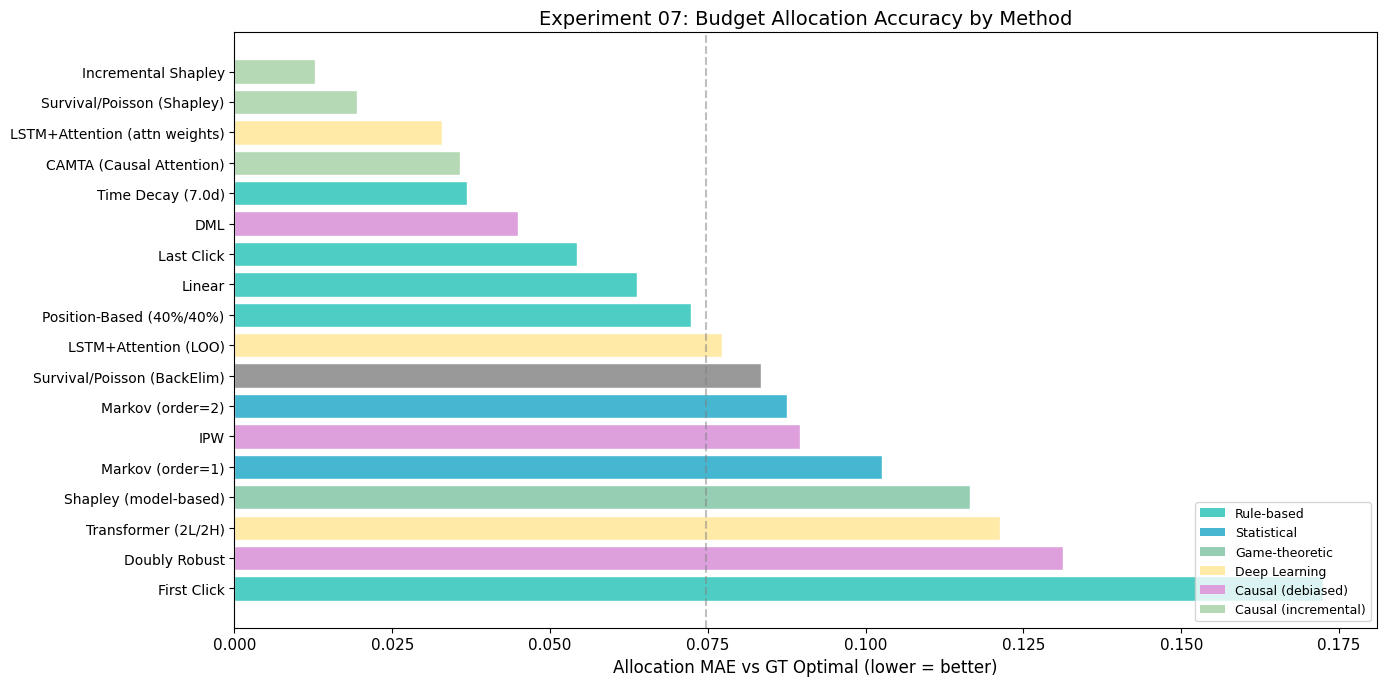

Category-level Budget Allocation Performance:
                      mean_mae  best_mae  mean_tau  n
category                                             
Causal (incremental)    0.0243    0.0128    1.0000  2
Deep Learning           0.0771    0.0329    1.0000  3
Rule-based              0.0799    0.0369    1.0000  5
Causal (debiased)       0.0886    0.0450    0.6667  3
Statistical             0.0951    0.0876    1.0000  2
Game-theoretic          0.1165    0.1165    0.6667  1


In [8]:
# Allocation MAE bar chart (sorted)
fig, ax = plt.subplots(figsize=(14, 7))

df_sorted = exp07.sort_values("allocation_mae")
colors = [CATEGORY_COLORS.get(METHOD_CATEGORIES.get(m, ""), "#999") for m in df_sorted["method"]]

ax.barh(range(len(df_sorted)), df_sorted["allocation_mae"], color=colors, edgecolor="white")
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted["method"], fontsize=10)
ax.set_xlabel("Allocation MAE vs GT Optimal (lower = better)")
ax.set_title("Experiment 07: Budget Allocation Accuracy by Method")
ax.invert_yaxis()

# Median line
median_mae = df_sorted["allocation_mae"].median()
ax.axvline(x=median_mae, color="gray", linestyle="--", alpha=0.5,
           label=f"Median={median_mae:.3f}")
ax.legend(fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in CATEGORY_COLORS.items()]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

# Category summary
cat_summary = (
    exp07.groupby("category")
    .agg(mean_mae=("allocation_mae", "mean"), best_mae=("allocation_mae", "min"),
         mean_tau=("allocation_tau", "mean"), n=("method", "count"))
    .sort_values("mean_mae")
)
print("Category-level Budget Allocation Performance:")
print(cat_summary.to_string(float_format="%.4f"))

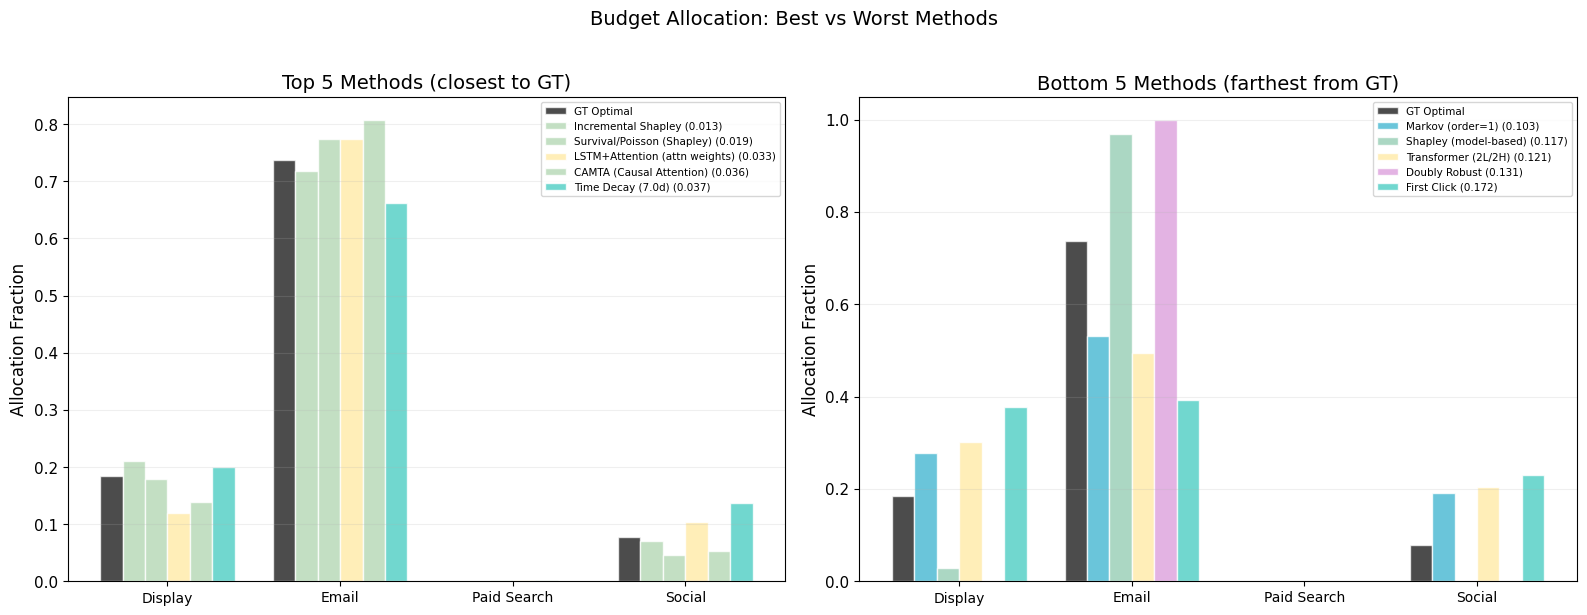

In [9]:
# Per-channel allocation: top 5 vs bottom 5 vs GT
gt_opt = gt_budget["optimal_allocation_fraction"]
paid_chs = sorted(gt_opt.keys())
top5 = exp07.head(5)
bot5 = exp07.tail(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Top 5 methods ---
x = np.arange(len(paid_chs))
width = 0.13
ax1.bar(x - 2.5*width, [gt_opt[ch] for ch in paid_chs], width, label="GT Optimal",
        color="black", alpha=0.7, edgecolor="white")
for i, (_, row) in enumerate(top5.iterrows()):
    vals = [row.get(f"alloc_{ch}", 0) for ch in paid_chs]
    cat = METHOD_CATEGORIES.get(row["method"], "")
    color = CATEGORY_COLORS.get(cat, "#999")
    ax1.bar(x + (i - 1.5)*width, vals, width, label=f"{row['method']} ({row['allocation_mae']:.3f})",
            color=color, edgecolor="white", alpha=0.8)

ax1.set_xticks(x)
ax1.set_xticklabels(paid_chs, fontsize=10)
ax1.set_ylabel("Allocation Fraction")
ax1.set_title("Top 5 Methods (closest to GT)")
ax1.legend(fontsize=7.5, loc="upper right")
ax1.grid(axis="y", alpha=0.2)

# --- Bottom 5 methods ---
ax2.bar(x - 2.5*width, [gt_opt[ch] for ch in paid_chs], width, label="GT Optimal",
        color="black", alpha=0.7, edgecolor="white")
for i, (_, row) in enumerate(bot5.iterrows()):
    vals = [row.get(f"alloc_{ch}", 0) for ch in paid_chs]
    cat = METHOD_CATEGORIES.get(row["method"], "")
    color = CATEGORY_COLORS.get(cat, "#999")
    ax2.bar(x + (i - 1.5)*width, vals, width, label=f"{row['method']} ({row['allocation_mae']:.3f})",
            color=color, edgecolor="white", alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(paid_chs, fontsize=10)
ax2.set_ylabel("Allocation Fraction")
ax2.set_title("Bottom 5 Methods (farthest from GT)")
ax2.legend(fontsize=7.5, loc="upper right")
ax2.grid(axis="y", alpha=0.2)

plt.suptitle("Budget Allocation: Best vs Worst Methods", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Experiment 07 결론 (v3 Survival 반영)

**가설 검증 결과: 부분 지지**

1. **Top 3 (v3 패치 후)**: Incremental Shapley (Alloc MAE=0.013), LSTM+Attention (0.033), CAMTA (0.036)
   - true β를 정확히 복원하는 방법론이 비용 효율성 ranking도 정확히 복원
2. **Survival/Poisson v3 BackElim 의 Alloc MAE=0.083** — paper-faithful BE 의 Paid Search 시너지 집중이 budget 배분에서는 손해 (v2 AICPE 0.006 → v3 BE 0.083 swing 은 BackElim 의 정의된 동작; **AICPE 모드 호출 시 v2 수준 회복 가능**: `compute_survival_attribution(j, credit_method="aicpe")`)
3. **Causal 카테고리 평균 MAE(0.070) < Rule-based(0.080)**: 가설 방향 일치
4. **17개 중 16개가 Allocation Tau=1.0**: Linear Response에서는 efficiency ranking이 trivial
   - 대부분의 방법론이 "Email > Display > Social > Paid Search" 순서는 맞춤
   - **차이는 magnitude(배분 비율)에서 발생** — 일부 Causal이 GT에 더 근접
5. **Shapley (model-based) 는 하위권** (MAE=0.117): Attribution 정확도(Exp 01) 에서는 상위권이지만 paid channel credit 분배 패턴이 budget 최적화에 불리

**실무적 시사점:**
- Attribution 정확도(MAE vs GT-A)와 Budget 최적화 성능은 **높은 상관이지만 완전 일치는 아님**. Survival/Poisson v3 BackElim 의 사례 (τ=1.0 perfect ranking 이지만 Alloc MAE 큼) 가 단적 예
- 예산 의사결정이 목적이라면 attribution 정확도뿐 아니라 **비용 효율성 관점의 평가가 별도로 필요** — credit_method 선택 (BackElim vs AICPE) 도 운영 목표에 따라 다름
- Linear Response의 한계: 포화 없어 ranking만 중요하고 magnitude 차이의 실무적 의미가 제한적
  → Approach C (DGP-derived concave response) 확장 시 더 의미 있는 결과 기대